In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.scripts.utils import get_workerlog_landlord_paths
from src.scripts.evaluate_current_estimate import *

In [18]:
landlord_paths = get_workerlog_landlord_paths("/Users/akshaykishan/PycharmProjects/iluvatar-faas/S4forIluvatar/src/data/runs/")

In [19]:
error_data = pd.DataFrame()
for i, path in enumerate(landlord_paths):
    print(f"session {i}")
    session_df = evaluate_current_estimate(path_to_log=path)
    session_df['session'] = int(i)
    error_data = pd.concat([error_data,  session_df])

session 0
Total Unified TIDs found with estimator pairs: 2554
Strictly GPU-Bound TIDs: 1049
TRUE Baseline MSE: 206.0463
TRUE Baseline MAE: 1.7437
TRUE Baseline Mean Perc. Relative Error: -651.2273%
TRUE Baseline Error StdDev: 14.3307
session 1
Total Unified TIDs found with estimator pairs: 2554
Strictly GPU-Bound TIDs: 746
TRUE Baseline MSE: 7.6353
TRUE Baseline MAE: 1.2449
TRUE Baseline Mean Perc. Relative Error: -156.9455%
TRUE Baseline Error StdDev: 2.6817
session 2
Total Unified TIDs found with estimator pairs: 3794
Strictly GPU-Bound TIDs: 1603
TRUE Baseline MSE: 22.7073
TRUE Baseline MAE: 1.7157
TRUE Baseline Mean Perc. Relative Error: -498.4805%
TRUE Baseline Error StdDev: 4.7033
session 3
Total Unified TIDs found with estimator pairs: 3794
Strictly GPU-Bound TIDs: 1009
TRUE Baseline MSE: 13.9659
TRUE Baseline MAE: 1.1795
TRUE Baseline Mean Perc. Relative Error: -227.6404%
TRUE Baseline Error StdDev: 3.6893
session 4
Total Unified TIDs found with estimator pairs: 3708
Strictly G

In [20]:
error_data.to_csv("current_estimation_model_raw_error_data.csv", index=False)

In [22]:
error_data[error_data.session>35][['fqdn', 'e2etime', 'gpu_est_total', 'absolute_error', 'squared_error', 'percentage_relative_error']].groupby('fqdn').mean()

,e2etime,gpu_est_total,absolute_error,squared_error,percentage_relative_error
fqdn,,,,,
onnx-roberta-0-0.0.1,1.539053,2.023569,1.636738,8.760254,-257.551065
onnx-roberta-1-0.0.1,2.005015,2.438895,1.983598,17.860955,-235.591640
onnx-roberta-2-0.0.1,1.848920,2.779502,2.015040,22.975770,-242.665383
onnx-roberta-3-0.0.1,2.885091,4.787729,3.677392,320.447014,-252.970530
onnx-roberta-4-0.0.1,3.632823,4.147584,2.411577,24.831862,-228.713936
pyhpc-eos-0-0.0.1,3.768214,6.709716,6.099011,84.757041,-11708.185213
pyhpc-eos-1-0.0.1,5.031849,10.303902,10.540697,315.204866,-7367.344222
pyhpc-eos-2-0.0.1,5.583516,4.843418,5.816782,123.196943,-4081.820638
pyhpc-eos-3-0.0.1,7.122989,7.396390,5.050737,56.595835,-2803.726939


In [49]:
def plot_session_latency_with_errors(df, x_col, y_col, err_col, save_path='current_model_error_metrics.png'):
    """
    Plots a bar chart where the bar height is y_col and 
    the error bar length is taken from err_col.
    """
    # Create the figure
    plt.bar(
        df[x_col].astype(str),   # Ensure sessions are treated as categories
        df[y_col], 
        yerr=df[err_col],        # Pulls error values from your column
        capsize=5,               # Adds horizontal 'caps' to the error bars
        color='lightcoral', 
        edgecolor='maroon',
        alpha=0.8
    )
    
    # Formatting
    plt.xlabel('Session ID')
    plt.ylabel('Error in prediction')
    plt.xticks(rotation=90)
    plt.title('Mean Error per Session with Standard Deviation')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Finalize
    plt.tight_layout()
    plt.savefig(save_path)

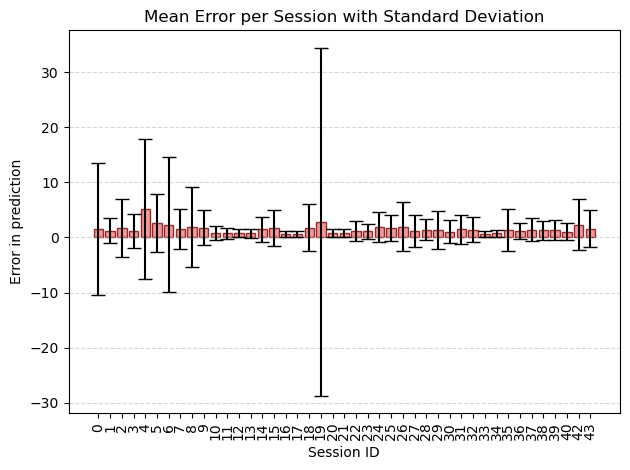

In [50]:
plot_session_latency_with_errors(error_df[error_df.session!=41], 'session', 'mae', 'std_error')

In [24]:
error_data[(error_data['session']>35) & (error_data['session']!=41)]['absolute_error'].mean()

1.4927811206124202

In [25]:
error_data[(error_data['session']>35) & (error_data['session']!=41)]['squared_error'].mean()

9.025957979617827

In [26]:
error_data[(error_data['session']>35) & (error_data['session']!=41)]['percentage_relative_error'].mean()

-228.4631983523789

In [29]:
error_data[(error_data.session>35) & (error_data.session!=41)][['fqdn', 'e2etime', 'gpu_est_total', 'absolute_error', 'squared_error', 'percentage_relative_error']].groupby('fqdn').mean().sort_values(by='percentage_relative_error')

,e2etime,gpu_est_total,absolute_error,squared_error,percentage_relative_error
fqdn,,,,,
pyhpc-eos-0-0.0.1,3.853172,6.920021,7.423396,122.913164,-16494.216788
pyhpc-eos-1-0.0.1,4.145709,6.818626,7.786634,166.608830,-7391.480653
pyhpc-eos-2-0.0.1,2.696285,3.989848,4.009754,20.039034,-6483.647894
pyhpc-eos-4-0.0.1,2.037581,6.981536,6.963167,291.292499,-4717.640325
pyhpc-eos-3-0.0.1,3.851988,5.253614,4.235972,26.769049,-3625.167517
pyhpc-isoneural-0-0.0.1,6.387356,8.758071,7.803968,128.522129,-3451.856085
pyhpc-isoneural-1-0.0.1,7.803349,8.466481,11.145107,192.470604,-3102.245663
pyhpc-isoneural-2-0.0.1,6.348540,6.523298,5.753590,38.173758,-1998.135372
torch_rnn-1-0.0.1,3.514626,4.243948,3.325624,23.267885,-1853.626866


In [33]:
error_data[(error_data['session']>35) & (error_data['session']!=41)][['fqdn', 'absolute_error']].groupby('fqdn').mean().sort_values(by='absolute_error', ascending=False)

,absolute_error
fqdn,
pyhpc-isoneural-1-0.0.1,11.145107
pyhpc-isoneural-3-0.0.1,9.912132
pyhpc-isoneural-0-0.0.1,7.803968
pyhpc-eos-1-0.0.1,7.786634
pyhpc-eos-0-0.0.1,7.423396
pyhpc-eos-4-0.0.1,6.963167
pyhpc-isoneural-4-0.0.1,6.174633
pyhpc-isoneural-2-0.0.1,5.753590
squeezenet-4-0.0.1,4.860916
